<a href="https://colab.research.google.com/github/chadiboudaher/pytorch-cat-dog-classifier/blob/main/dog_cat_classifier_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import torch
import torch
from torch import nn
from torch.utils.data import DataLoader

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Resize

# Import data processing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"The used device is {device}")
print(f"PyTorch version is {torch.__version__}")
print(f"PyTorch vision version is {torchvision.__version__}")

The used device is cuda
PyTorch version is 2.11.0+cu128
PyTorch vision version is 0.26.0+cu128


# 1. Get data

The dataset is a part of the torchvision datasets

In [2]:
transform = Compose([
    Resize((224, 224)),
    ToTensor()
])

# Get train data
train_data = datasets.OxfordIIITPet(root="data",
                                    split="trainval",
                                    transform=transform,
                                    download=True)

# Get test data
test_data = datasets.OxfordIIITPet(root="data",
                                   split="test",
                                   transform=transform,
                                   download=True)

100%|██████████| 792M/792M [00:35<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.7MB/s]


In [3]:
len(train_data), len(test_data)

(3680, 3669)

In [4]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label shape: {label}")

Image shape: torch.Size([3, 224, 224])
Label shape: 0


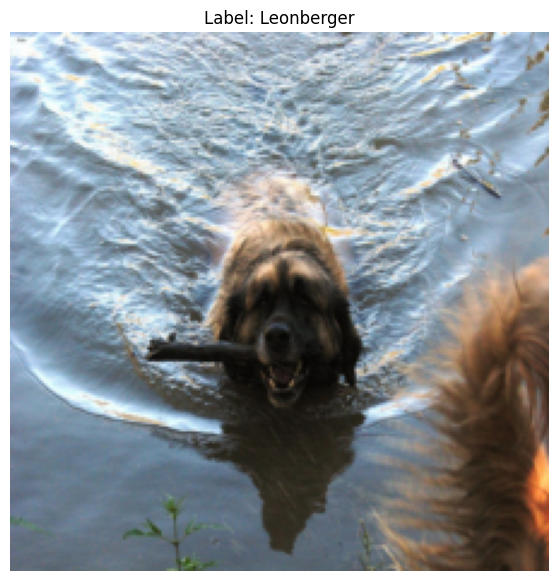

In [5]:
# Set random seed
torch.manual_seed(42)
random_idx = torch.randint(low=0, high=len(train_data), size=[1]).item()
image, label = train_data[random_idx]
plt.figure(figsize=(10, 7))
# [channels, height, weight] -> [height, weight, channels]
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {train_data.classes[label]}")
plt.axis(False)
plt.show();

# 2. Turn them into DataLoader

In [6]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [7]:
len(train_dataloader), len(test_dataloader)

(115, 115)

# 3. Build a Baseline model

In [8]:
class Petv0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

In [13]:
model_0 = Petv0(input_shape=224*224,
                hidden_units=10,
                output_shape=2).to(device)
model_0

Petv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=2, bias=True)
  )
)

# 4. Setup loss function and optimizer

In [14]:
import requests
from pathlib import Path

# Download helper function from learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exist, skipping download...")
else:
  print("Downloading helper functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exist, skipping download...


In [15]:
from helper_functions import accuracy_fn

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.1)

In [16]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """ Prints difference between start and end time """

  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

# 5. Creating a training loop and training a model on batches of data

it would be better to create:
1. train_step function
2. test_step function

In [18]:
from tqdm.auto import tqdm

# Create train step
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  # Initialize train loss and train accuracy variable
  train_loss, train_acc = 0, 0

  # Setup train mode
  model.train()

  # loop through the training batches
  for batch, (X, y) in enumerate(data_loader):
    # Put data on target device
    X, y = X.to(device), y.to(device)

    # Forward pass
    y_pred = model(X)

    # calculate accuracy and loss per batch
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

    # Optimizer zero grad
    optimizer.zero_grad()

    # Back prop
    loss.barckward

    # optimizer step
    optimizer.step()

  # Divide total train loss and accuracy by length of train dataloader
  train_loss = train_loss / len(data_loader)
  train_acc = train_acc / len(data_loader)

  # Print output
  print(f"Train Loss: {train_loss:.5f} | Train acc: {train_acc:.5f}%")